In [1]:
import jax
import jax.numpy as jnp
import nifty8 as ift
import numpy as np
import resolve as rve

from jax.lax import slice as jax_slice

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type

jax.config.update("jax_enable_x64", True)

Could not import MPI
/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class SignalGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, space, center=(0,0), factor=1, distances=(1.,1.)):
        check_type(space, tuple, int)
        check_type(factor, int)
        check_type(center, tuple, int)
        check_type(distances, tuple, float)

        self.space = space
        self.center = center
        self.factor = factor
        self.shape = tuple(d*self.factor for d in self.space)
        self.distances = distances

    def __repr__(self):
        return f'SignalGrid(space={self.space}, center={self.center}, factor={self.factor}, distances={self.distances})'

    @property
    def dom(self):
        return np.array(self.space)

    @property
    def cen(self):
        return np.array(self.center)
    
    @property
    def shp(self):
        return np.array(self.shape)

    @property
    def size(self):
        return self.shp.prod()
    
    @property
    def dis(self):
        return np.array(self.distances) / self.factor
    
    @property
    def coos(self):
        coos = np.indices(self.shp).astype(float)
        coos_T = coos.T.reshape(-1, 2)
        coos_T -= 0.5 * (self.shp - 1)
        coos_T /= self.factor
        coos_T += self.cen
        return coos_T.reshape(coos.T.shape).T

    @property
    def llp(self):
        return self.cen - 0.5 * (self.shp - 1) / self.factor

    @property
    def urp(self):
        return self.cen + 0.5 * (self.shp - 1) / self.factor

    def update(self, space=None, center=None, factor=None, distances=None):
        space = self.space if space is None else space
        center = self.center if center is None else center
        factor = self.factor if factor is None else factor
        distances = self.distances if distances is None else distances
        return SignalGrid(space, center, factor, distances)



def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    

def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor, axis=0).repeat(factor, axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def map_array(in_array, in_grid, out_grid):
    factor = 1
    if out_grid.factor < in_grid.factor:
        in_array = downsample(in_array, in_grid.factor // out_grid.factor)
        in_grid = in_grid.update(factor=out_grid.factor)
    else:
        factor = out_grid.factor // in_grid.factor
        out_grid = out_grid.update(factor=in_grid.factor)

    if in_grid.center != out_grid.center or in_grid.space != out_grid.space:
        out_array = np.zeros(out_grid.shape)

        llp_dif = (out_grid.llp - in_grid.llp).astype('int64')
        urp_dif = (out_grid.urp - in_grid.urp).astype('int64')

        in_min = np.maximum(llp_dif * in_grid.factor, 0)
        in_max = np.minimum(urp_dif * in_grid.factor + in_grid.shp, in_grid.shp)
        in_slc = tuple(slice(in_min[i], in_max[i]) for i in range(2))

        out_min = np.maximum(- llp_dif * out_grid.factor, 0)
        out_max = np.minimum(out_grid.shp - urp_dif * out_grid.factor, out_grid.shp)
        out_slc = tuple(slice(out_min[i], out_max[i]) for i in range(2))
        
        out_array[out_slc] = in_array[in_slc]
    else:
        out_array = in_array.copy()

    if factor > 1:
        out_array = upsample(out_array, factor)

    return out_array



class PointGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, coordinates, factor=1, n_copies=1):
        check_type(coordinates, tuple, tuple, float)
        check_type(factor, int)
        check_type(n_copies, int)

        self.coordinates = coordinates
        self.factor = factor
        self.n_copies = n_copies
        self.shape = (1, 1)

    def __repr__(self):
        return f'PointGrid(coordinates={self.coordinates}, factor={self.factor}, n_copies={self.n_copies})'

    @property
    def coos(self):
        return np.array(self.coordinates)
    
    @property
    def shp(self):
        return np.array(self.shape)

    @property
    def size(self):
        return self.shp.prod()

    def update(self, coordinates=None, factor=None, n_copies=None):
        coordinates = self.coordinates if coordinates is None else coordinates
        factor = self.factor if factor is None else factor
        n_copies = self.n_copies if n_copies is None else n_copies
        return PointGrid(coordinates, factor, n_copies)



def map_point(in_array, in_grid, out_grid):
    if out_grid.factor < in_grid.factor:
        factor = out_grid.factor / in_grid.factor
        in_coos = np.floor(in_grid.coos * out_grid.factor) / out_grid.factor + 0.5 / out_grid.factor
        in_grid = in_grid.update(coordinates=tuple(map(tuple, in_coos.tolist())), factor=out_grid.factor)
    else:
        factor = out_grid.factor // in_grid.factor
        out_grid = out_grid.update(factor=in_grid.factor)

    out_array = np.zeros(out_grid.shape)

    for i in range(in_grid.n_copies):
        llp_dif = (out_grid.factor * (in_grid.coos[i] - out_grid.llp)).astype('int64')
        out_array[llp_dif[0], llp_dif[1]] += in_array[i,0,0] * factor**2
        
    if factor > 1:
        out_array = upsample(out_array, factor)

    return out_array

In [3]:
def build_exact_responses(
        obs,
        space,
):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l



def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val



def compute_noise_kernel(RNR, relativ_min_val=0.):
    '''Build the inverse noise kernel for the given RNR operator.'''
    dom = RNR.domain
    shp = dom.shape
    FFT = ift.FFTOperator(RNR.domain)

    delta = np.zeros(shp)
    delta[shp[0]//2, shp[1]//2] = 1 / dom.scalar_weight()
    delta = ift.makeField(dom, delta)
    kernel = RNR(delta).val
    kernel = np.roll(kernel, -shp[0]//2, axis=0)
    kernel = np.roll(kernel, -shp[1]//2, axis=1)
    kernel = ift.makeField(RNR.target, kernel)
    FFT = ift.FFTOperator(RNR.domain)
    max_val = np.max(FFT(kernel).abs().val)
    min_val = relativ_min_val * max_val
    min_val = ift.full(FFT.target, min_val)
    min_val_adder = ift.Adder(min_val)

    pos_eig_val = ift.Operator.identity_operator(FFT.target).exp()
    pos_eig_val = min_val_adder @ pos_eig_val
    rls1 = ift.Realizer(pos_eig_val.target)
    rls2 = ift.Realizer(FFT.domain)

    kernel_pos = rls2 @ FFT.inverse @ rls1.adjoint @ pos_eig_val

    cov = ift.ScalingOperator(kernel_pos.target, 1e-2*max_val)
    lh = ift.GaussianEnergy(data=kernel, inverse_covariance=cov.inverse) @ kernel_pos
    init_pos = (FFT(kernel) - min_val).abs().log()
    energy = ift.EnergyAdapter(position=init_pos, op=lh, want_metric=True)

    ic_newton = ift.DeltaEnergyController(name='Newton', iteration_limit=80, tol_rel_deltaE=0)
    minimizer = ift.NewtonCG(ic_newton)
    res = minimizer(energy)[0].position

    return pos_eig_val(res).val

In [4]:
obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()
print(obs)

Observation:
  Source name:		None
  Visibilities shape:	(1, 3668965, 7)
  # visibilities:	25682755
  Frequency range:	986.720 -- 1137.188 MHz
  Polarizations:	I
  Shortest baseline:	0.0 m -> inf deg
  Longest baseline:	7697.6 m -> 7.064 arcsec
  Flagged:		38.1%


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/resolve/data/observation.py:754: RuntimeWarning: divide by zero encountered in scalar divide
  short1 = 1/(short0*self.freq.min()/SPEEDOFLIGHT)


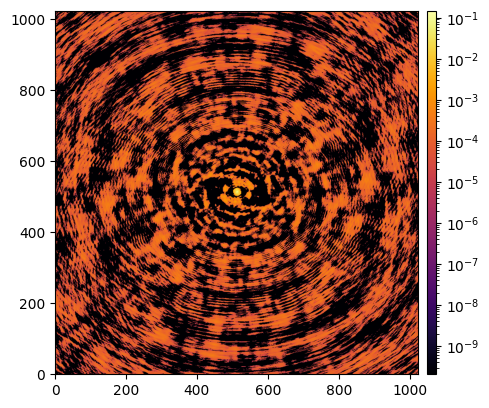

In [5]:
space_512 = SignalSpace.build(shape=(512,512), fov=('1deg', '1deg'))

R, R_l, RNR, RNR_l = build_exact_responses(obs, space_512)

kernel_512 = compute_psf_kernel(RNR_l)

plot_arrays(kernel_512, norm='log', dpi=100)

In [6]:
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, get_builders, map_signal


base_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/base.yml'
exp_yml = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_pre.yml'

optim_cfg = OptimizeKLConfig.from_file((base_yml, exp_yml), get_builders, 'total')



exp_it = 3
sky_it = optim_cfg.instantiate_sec(f'sky.{exp_it}')

skies_c, means_c = [], []
with open('/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/opt/3_rec/last.pkl', "rb") as f:
    smp_c, *_ = pickle.load(f)
for sky_c in sky_it.signals + sky_it.points:
    print(sky_c.prefix)
    mean = smp_c.mean(sky_c)
    skies_c += [sky_c, ]
    means_c += [map_signal(mean, sky_c.space, skies_c[0].space), ]

signal_bg, space_bg = downsample(means_c[0], 1), skies_c[0].space * 1
signal_t0, space_t0 = downsample(means_c[1], 1), skies_c[1].space * 1
signal_t1, space_t1 = downsample(means_c[2], 1), skies_c[2].space * 1
signal_t2, space_t2 = downsample(means_c[3], 1), skies_c[3].space * 1
signal_ps, mean_ps = downsample(means_c[4], 1), smp_c.mean(sky_it.points[0].points)
signal_sum = signal_bg + signal_t0 + signal_t1 + signal_t2 + signal_ps
signal_ps = signal_ps.at[0,0].set(1e-3)

bg.3
o0.3
o1.3
o2.3
p0.3


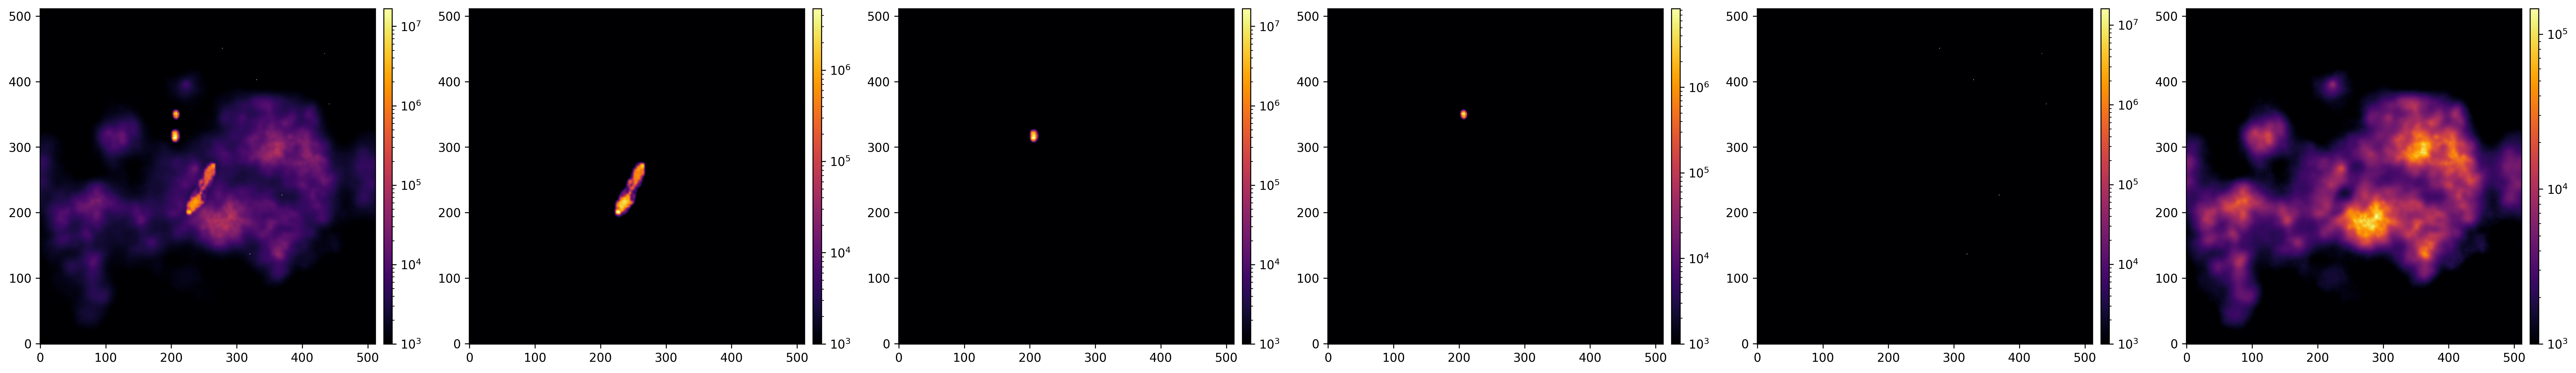

In [7]:
zoom = 4

dis = tuple(d*zoom for d in space_bg.distances)
grid_sum = SignalGrid(space=(512//zoom, 512//zoom), center=(0, 0), factor=zoom, distances=dis)
grid_bg = SignalGrid(space=(512//zoom, 512//zoom), center=(0, 0), factor=1, distances=dis)
grid_t0 = SignalGrid(space=(80//zoom, 112//zoom), center=(-8//zoom, -16//zoom), factor=zoom, distances=dis)
grid_t1 = SignalGrid(space=(40//zoom, 40//zoom), center=(-48//zoom, 62//zoom), factor=zoom, distances=dis)
grid_t2 = SignalGrid(space=(32//zoom, 40//zoom), center=(-48//zoom, 96//zoom), factor=zoom, distances=dis)

ps_coos = np.argwhere(signal_ps > 1)
ps_new = np.zeros_like(ps_coos).astype('float64')
for i in range(ps_coos.shape[0]):
    ps_new[i,:] = grid_sum.coos[:, ps_coos[i,0], ps_coos[i,1]]
grid_p0 = PointGrid(coordinates=tuple(map(tuple, ps_new.tolist())), factor=zoom, n_copies=ps_new.shape[0])

signal_dict = {
    'sum': {'val': signal_sum, 'low': downsample(signal_sum, zoom), 'spc': grid_sum},
    't0': {'val': signal_t0, 'low': downsample(signal_t0, zoom), 'spc': grid_t0},
    't1': {'val': signal_t1, 'low': downsample(signal_t1, zoom), 'spc': grid_t1},
    't2': {'val': signal_t2, 'low': downsample(signal_t2, zoom), 'spc': grid_t2},
    'ps': {'val': signal_ps, 'low': downsample(signal_ps, zoom), 'spc': grid_p0, 'pix': mean_ps},
    'bg': {'val': signal_bg, 'low': downsample(signal_bg, zoom), 'spc': grid_bg},
    'fac': zoom,
}

kernel = kernel_512.copy()

plot_arrays([sig['val'] for sig in signal_dict.values() if isinstance(sig, dict)], norm='log', dpi=300, rows=1, vmin=1e3)

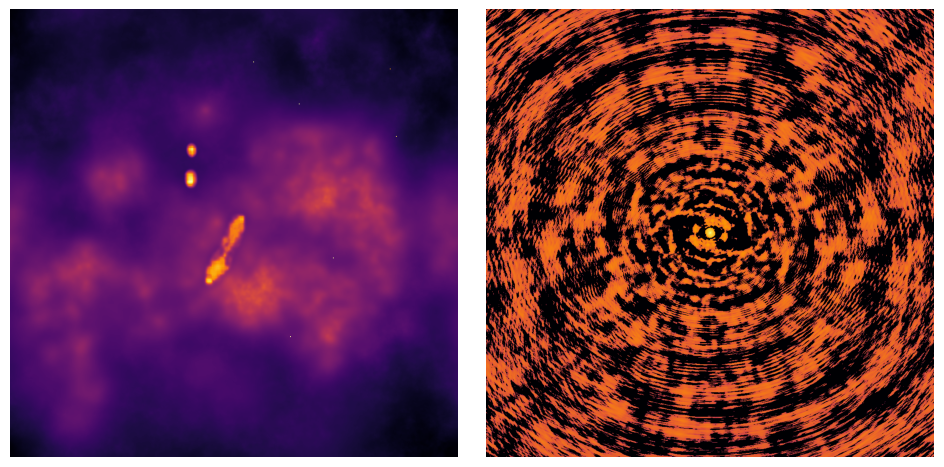

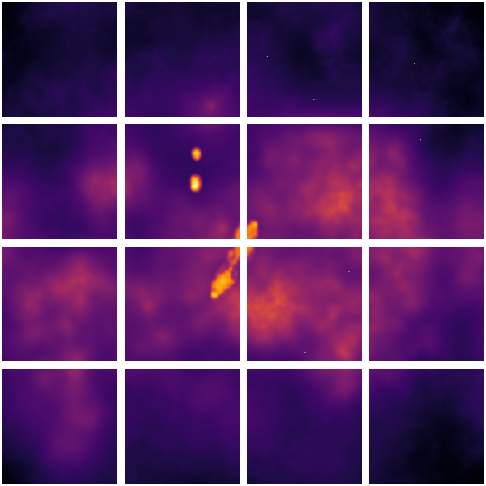

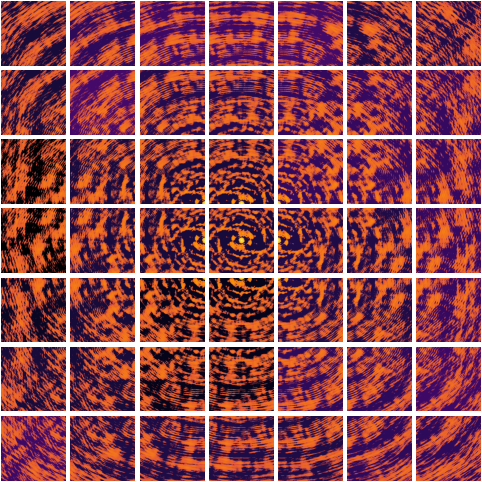

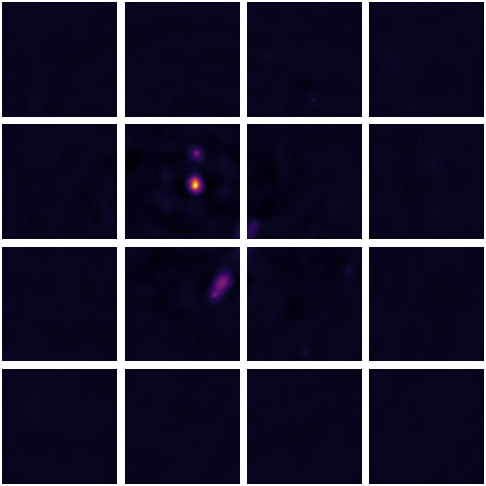

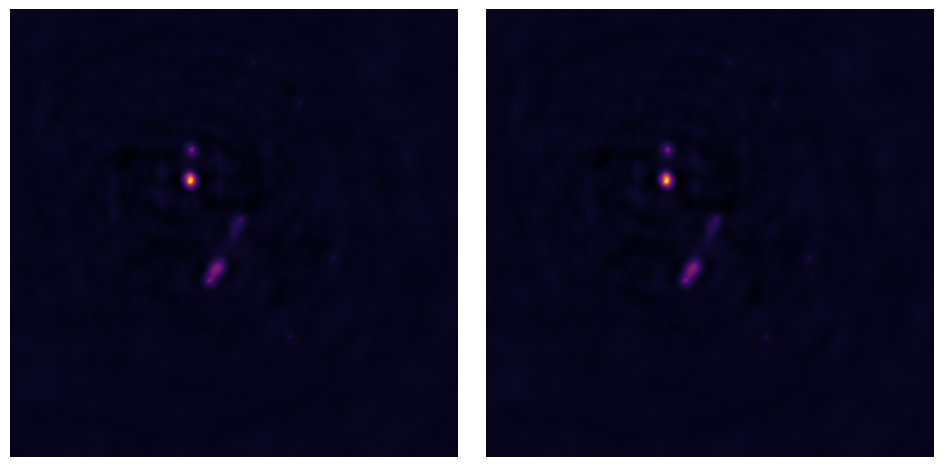

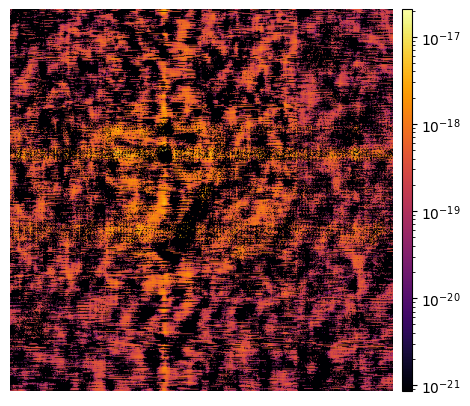

In [8]:
def jax_fft(grid):
    check_type(grid, SignalGrid)
    dvol = grid.dis.prod()
    return lambda x: dvol * jnp.fft.fftn(x)


def jax_ifft(grid):
    check_type(grid, SignalGrid)
    dvol = 1. / (grid.shp * grid.dis).prod()
    npix = grid.size
    return lambda x: dvol * npix * jnp.fft.ifftn(x)


def jax_fft_convolve(fft_kernel, grid):
    grid_l = grid.update(space=tuple(s*2 for s in grid.space))
    fft_l = jax_fft(grid_l)
    ifft_l = jax_ifft(grid_l)
    padding = grid.shp // 2

    def jax_fft_conv(array):
        p_array = jnp.pad(array, (2*(padding[0],), 2*(padding[1],)))
        c_array = ifft_l(fft_kernel * fft_l(p_array)).real
        s_array = jax_slice(c_array, padding, padding + grid.shp)
        return s_array

    return jax_fft_conv


def shift_kernel(kernel):
    s_kernel = jnp.roll(kernel, -kernel.shape[0]//2, axis=0)
    s_kernel = jnp.roll(s_kernel, -kernel.shape[1]//2, axis=1)
    return s_kernel


def build_fft_kernel(kernel, grid):
    check_type(grid, SignalGrid)
    grid_l = grid.update(space=tuple(s*2 for s in grid.space))
    s_kernel = shift_kernel(kernel)
    f_kernel = jax_fft(grid_l)(s_kernel)
    return f_kernel


def facet_center(factor, shape):
    f_coos = np.linspace(1/factor, 2 - 1/factor, 2*factor - 1)
    f_center = np.array(np.meshgrid(f_coos, f_coos)).T.reshape(-1, 2)
    return f_center * np.array(shape) // 2


def build_facet_kernel(kernel, f_grid, factor):
    f_center = facet_center(factor, kernel.shape)
    n_f = f_center.shape[0]
    f_shape = tuple(s//factor for s in kernel.shape)

    f_kernel = np.zeros((n_f,) + f_shape, dtype='complex128')
    for i in range(n_f):
        slc_i = tuple(slice(int(c) - s//2, int(c) + s//2) for c, s in zip(f_center[i], f_shape))
        f_ker = kernel[slc_i]
        f_kernel[i] = build_fft_kernel(f_ker, f_grid)
    return f_kernel


def build_facet_array(array, factor):
    f_shape = tuple(s//factor for s in array.shape)
    f_array = array.reshape(factor, f_shape[0], factor, f_shape[1])
    f_array = f_array.transpose(0,2,1,3)
    f_array = f_array.reshape(-1, f_shape[0], f_shape[1])
    return f_array


def merge_facet_array(f_array, factor):
    f_shape = f_array.shape[1:]
    array = f_array.reshape(factor, factor, f_shape[0], f_shape[1])
    array = array.transpose(0, 2, 1, 3)
    array = array.reshape(factor*f_shape[0], factor*f_shape[1])
    return array


def facet_indices(factor):
    coos = np.arange(factor)
    a_idx = np.array(np.meshgrid(coos, coos)).T.reshape(-1, 2)
    k_idx = np.arange((2*factor - 1)**2).reshape((2*factor - 1, 2*factor - 1))

    f_idx = np.empty((factor**2, factor**2), dtype='int64')
    for i in range(factor**2):
        slc_i = tuple(slice(int(a_idx[i][j]), int(a_idx[i][j]) + factor) for j in range(2))
        f_idx[i] = k_idx[slc_i].flatten()
    return f_idx[::-1]


def reorder_facet_array(array):
    factor = int(np.sqrt(array.shape[0]))
    grid = np.arange(factor**2).reshape((factor, factor))
    order = grid.T[::-1].flatten()
    return array[order]


def facet_convolve(f_kernel, f_idx, f_grid, factor):

    def facet_conv(array):
        f_array = build_facet_array(array, factor)
        n_f = f_array.shape[0]

        f_response = np.zeros((n_f,) + f_array.shape)
        for i in range(n_f):
            f_arr = f_array[i]

            for j in range(n_f):
                f_ker = f_kernel[f_idx[i,j]]
                f_con = jax_fft_convolve(f_ker, f_grid)(f_arr)
                f_response[i,j] = f_con

        f_response = f_response.sum(axis=0)

        plot_arrays(reorder_facet_array(f_array), dpi=100//factor, vmin=f_array.min(), vmax=f_array.max(), norm='log', ticks=0, cbar=False)
        r_kernel = jax.vmap(lambda k: shift_kernel(jax_ifft(f_grid)(k)).real)(jnp.array(f_kernel))
        plot_arrays(reorder_facet_array(r_kernel), dpi=100//(2*factor-1), vmin=r_kernel[r_kernel>0].min(), vmax=r_kernel.max(), norm='log', ticks=0, cbar=False)
        plot_arrays(reorder_facet_array(f_response), dpi=100//factor, vmin=f_response.min(), vmax=f_response.max(), ticks=0, cbar=False)

        response = merge_facet_array(f_response, factor)
        return response
    
    return facet_conv


def jax_facet_convolve(f_kernel, f_idx, f_grid, factor):

    def jax_facet_conv(array):
        f_array = build_facet_array(array, factor)

        def inner(i, j):
            f_arr = f_array[i]
            f_ker = f_kernel[f_idx[i, j]]
            return jax_fft_convolve(f_ker, f_grid)(f_arr)

        def per_i(i):
            return jax.vmap(lambda j: inner(i, j))(jnp.arange(factor**2))

        f_response = jax.vmap(per_i)(jnp.arange(factor**2))
        f_response = f_response.sum(axis=0)
        response = merge_facet_array(f_response, factor)
        return response
    
    return jax_facet_conv


def facet_response(array, kernel, grid, factor, plot=False):
    f_grid = grid.update(space=tuple(s//factor for s in grid.space))
    f_kernel = build_facet_kernel(kernel, f_grid, factor)
    f_idx = facet_indices(factor)

    if plot:
        response = facet_convolve(f_kernel, f_idx, f_grid, factor)(array)
    else:
        response  = jax_facet_convolve(jnp.array(f_kernel), jnp.array(f_idx), f_grid, factor)(jnp.array(array))

    return response



sig = signal_dict['sum']['val']
ker = kernel
fac = 4
grd = signal_dict['sum']['spc']

plot_arrays([sig, ker], dpi=100, norm='log', ticks=0, cbar=False, rows=1)
frsp = facet_response(sig, ker, grd, fac, True)
hrsp = jax_fft_convolve(build_fft_kernel(ker, grd), grd)(sig)

plot_arrays([frsp, hrsp], dpi=100, ticks=0, cbar=False, rows=1)
plot_arrays(frsp - hrsp, dpi=100, norm='log', ticks=0, cbar=True, rows=1)

In [15]:
import jax
import jax.numpy as jnp
import time

# -----------------
# Benchmark helper
# -----------------

def benchmark(fn, *args, n_warmup=3, n_iter=10):
    # Warmup (to trigger compilation & JIT)
    fn(*args).block_until_ready()
    for _ in range(n_warmup):
        fn(*args).block_until_ready()

    # Timing
    start = time.time()
    for _ in range(n_iter):
        fn(*args).block_until_ready()
    end = time.time()

    return (end - start) / n_iter

# -----------------
# Run test
# -----------------

if __name__ == "__main__":
    key = jax.random.key(0)
    shape = (2048, 2048)
    fac = 2
    grd = SignalGrid(space=shape)

    arr = jax.random.normal(key, shape)
    ker = jax.random.normal(key, tuple(s*2 for s in shape))

    f_grd = grd.update(space=tuple(s//fac for s in grd.space))
    f_ker = build_facet_kernel(ker, f_grd, fac)
    f_idx = facet_indices(fac)

    h_ker = build_fft_kernel(ker, grd)

    f_fun = jax_facet_convolve(jnp.array(f_ker), jnp.array(f_idx), f_grd, fac)
    h_fun = jax_fft_convolve(jnp.array(h_ker), grd)

    # JIT compile
    f_jit_fun = jax.jit(f_fun)
    h_jit_fun = jax.jit(h_fun)

    t_facet = benchmark(f_jit_fun, arr)
    t_whole= benchmark(h_jit_fun, arr)

    print(f"facet fft conv:  {t_facet:.4f} sec")
    print(f"whole fft conv:  {t_whole:.4f} sec")
    print(f"Backend: {jax.default_backend()}")


facet fft conv:  2.4314 sec
whole fft conv:  0.8369 sec
Backend: cpu
